In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

quality_df = pd.read_csv("../data/image_quality_metrics.csv")
infodump_df = pd.read_csv("../data/raw_subject_data.csv")

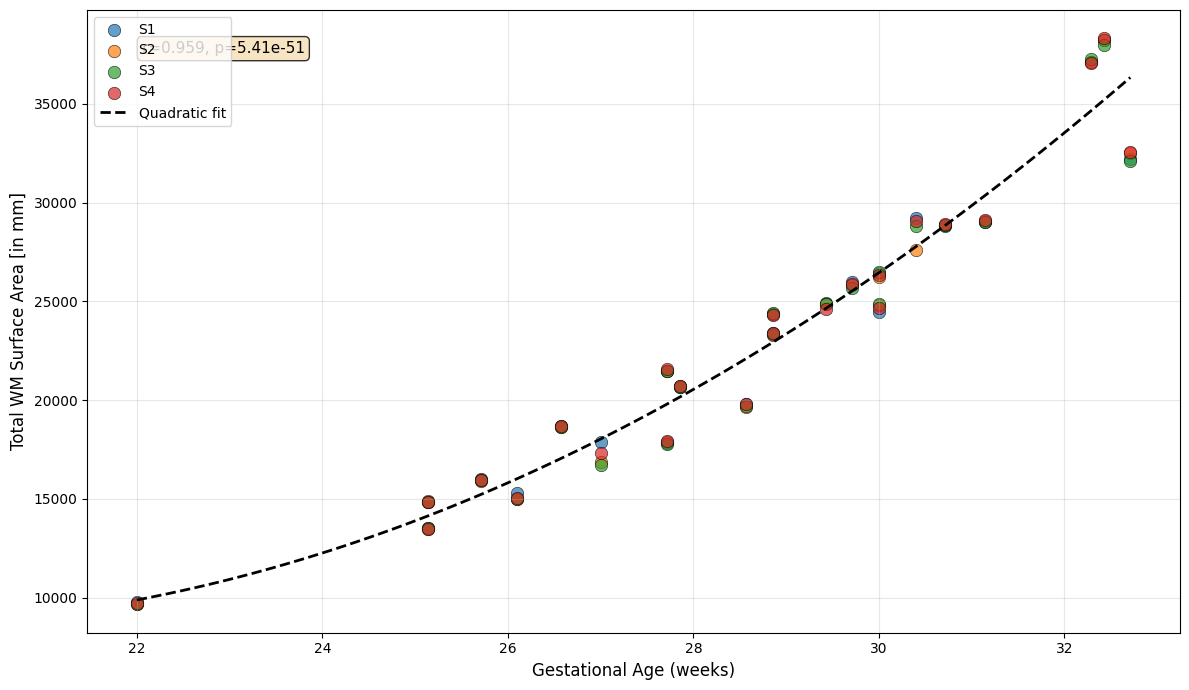

In [14]:
fig, ax = plt.subplots(figsize=(12, 7))

split_colors = {'S1': '#1f77b4', 'S2': '#ff7f0e', 'S3': '#2ca02c', 'S4': '#d62728'}

for split in ['S1', 'S2', 'S3', 'S4']:
    split_data = quality_df[quality_df['split'] == split]
    ax.scatter(split_data['GA'], split_data['wm_surface_area'],
              label=split, color=split_colors[split], s=80, alpha=0.7, edgecolors='black', linewidth=0.5)

ga_vals = quality_df['GA'].values
surface_vals = quality_df['wm_surface_area'].values
valid_idx = ~(np.isnan(ga_vals) | np.isnan(surface_vals))
ga_clean = ga_vals[valid_idx]
surface_clean = surface_vals[valid_idx]

coeffs = np.polyfit(ga_clean, surface_clean, 2)
poly = np.poly1d(coeffs)
ga_range = np.linspace(ga_clean.min(), ga_clean.max(), 100)
ax.plot(ga_range, poly(ga_range), 'k--', linewidth=2, label='Quadratic fit')

r, p = stats.pearsonr(ga_clean, surface_clean)
ax.text(0.05, 0.95, f'r={r:.3f}, p={p:.2e}', transform=ax.transAxes, 
        fontsize=11, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

ax.set_xlabel('Gestational Age (weeks)', fontsize=12)
ax.set_ylabel('Total WM Surface Area [in mm]', fontsize=12)
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

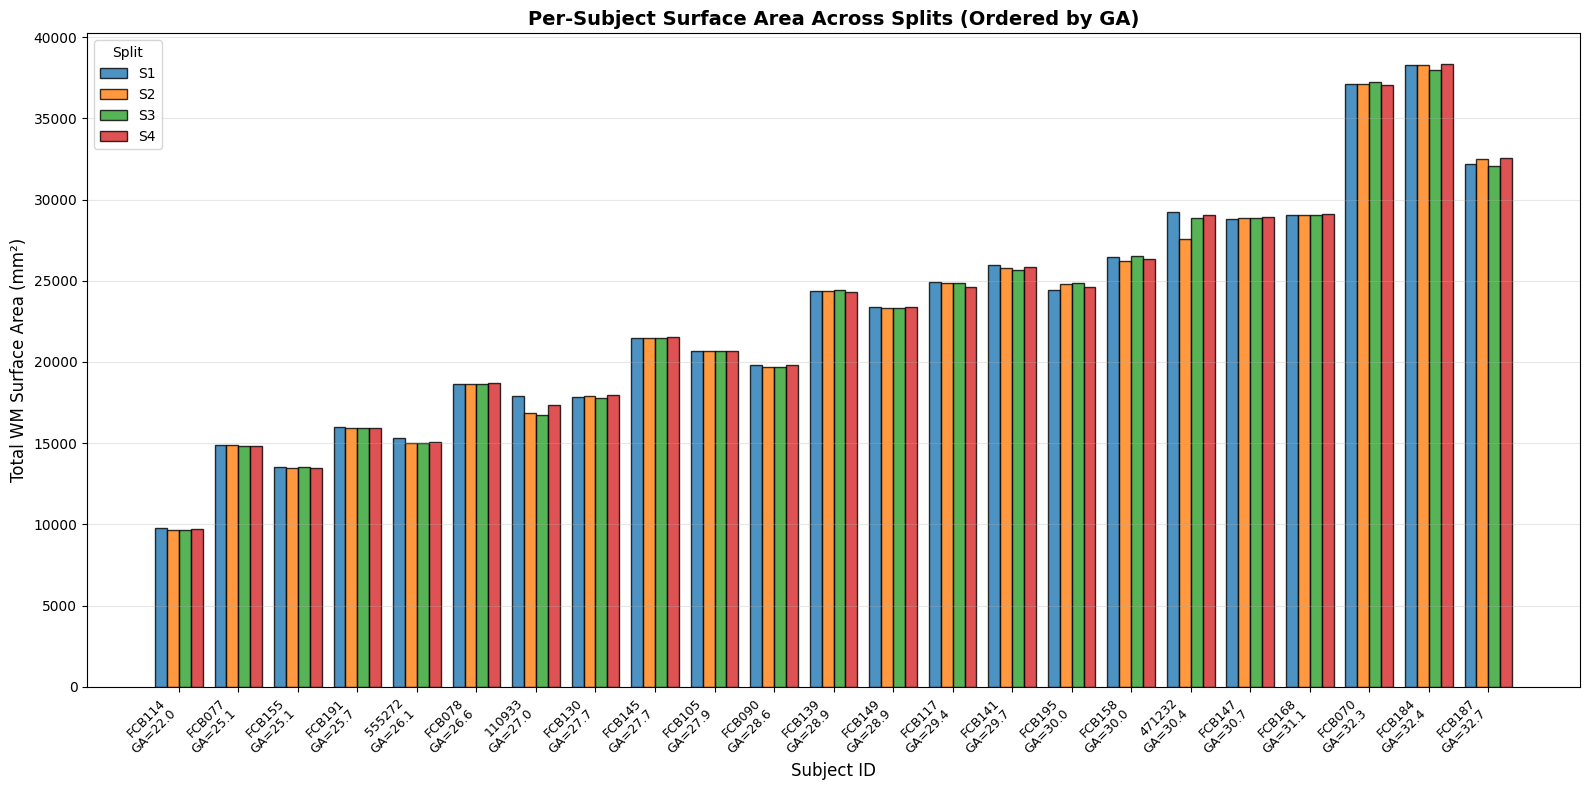

In [20]:
fig, ax = plt.subplots(figsize=(16, 8))

subjects_sorted = subjects_ga.sort_values('GA')
x = np.arange(len(subjects_sorted))
width = 0.2
split_colors = {'S1': '#1f77b4', 'S2': '#ff7f0e', 'S3': '#2ca02c', 'S4': '#d62728'}

for i, split in enumerate(['S1', 'S2', 'S3', 'S4']):
    values = []
    for _, row in subjects_sorted.iterrows():
        subj_id = row['subject_id']
        sess_id = row['session_id']
        data = quality_df[(quality_df['subject_id'] == subj_id) &
                          (quality_df['session_id'] == sess_id) &
                          (quality_df['split'] == split)]['wm_surface_area']
        values.append(data.values[0] if len(data) > 0 else np.nan)

    offset = (i - 1.5) * width
    ax.bar(x + offset, values, width, label=split, color=split_colors[split], alpha=0.8, edgecolor='black')

tick_labels = [f"{str(row['subject_id'])[:6]}\nGA={row['GA']:.1f}" for _, row in subjects_sorted.iterrows()]
ax.set_xticks(x)
ax.set_xticklabels(tick_labels, fontsize=9, rotation=45, ha='right')
ax.set_xlabel('Subject ID', fontsize=12)
ax.set_ylabel('Total WM Surface Area (mm²)', fontsize=12)
ax.set_title('Per-Subject Surface Area Across Splits (Ordered by GA)', fontsize=14, fontweight='bold')
ax.legend(title='Split', loc='upper left')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

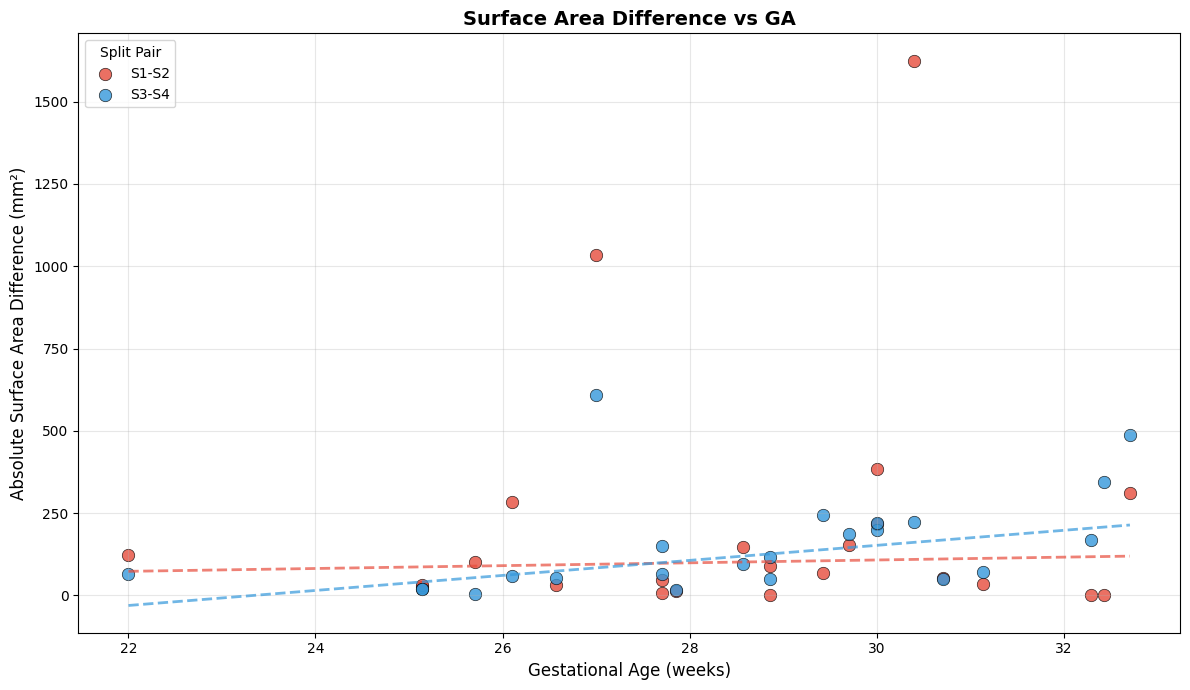

In [16]:
split_pair_diffs = pd.read_csv("../data/split_comparision_data.csv")

def _compute_split_pair_diff(df, col_name, split1, split2, relative=False):
    """Compute differences between two splits for a given column."""
    pairs = []
    for (subj_id, sess_id), group in df.groupby(['subject_id', 'session_id']):
        s1_data = group[group['split'] == split1][col_name]
        s2_data = group[group['split'] == split2][col_name]

        if len(s1_data) > 0 and len(s2_data) > 0:
            val1 = s1_data.values[0]
            val2 = s2_data.values[0]

            if pd.notna(val1) and pd.notna(val2):
                diff = abs(val1 - val2)
                if relative and val1 != 0:
                    diff = (diff / abs(val1)) * 100

                pairs.append({
                    'subject_id': subj_id,
                    'session_id': sess_id,
                    'split_pair': f"{split1}-{split2}",
                    'GA': group['GA'].iloc[0],
                    'diff': diff
                })

    return pd.DataFrame(pairs)

surface_diffs_s1s2 = _compute_split_pair_diff(quality_df, 'wm_surface_area', 'S1', 'S2', relative=False)
surface_diffs_s3s4 = _compute_split_pair_diff(quality_df, 'wm_surface_area', 'S3', 'S4', relative=False)
surface_diffs_all = pd.concat([surface_diffs_s1s2, surface_diffs_s3s4], ignore_index=True)

from sklearn.linear_model import RANSACRegressor

fig, ax = plt.subplots(figsize=(12, 7))
colors = {'S1-S2': '#e74c3c', 'S3-S4': '#3498db'}

for pair_name in ['S1-S2', 'S3-S4']:
    pair_data = surface_diffs_all[surface_diffs_all['split_pair'] == pair_name]
    ga_vals = pair_data['GA'].values
    diff_vals = pair_data['diff'].values

    ax.scatter(ga_vals, diff_vals, c=colors[pair_name], s=80, alpha=0.8,
              edgecolors='black', linewidths=0.5, label=pair_name)

    if len(ga_vals) >= 4:
        X = ga_vals.reshape(-1, 1)
        ransac = RANSACRegressor(residual_threshold=np.std(diff_vals), min_samples=0.7, random_state=42)
        ransac.fit(X, diff_vals)
        x_line = np.linspace(ga_vals.min(), ga_vals.max(), 100).reshape(-1, 1)
        y_line = ransac.predict(x_line)
        ax.plot(x_line, y_line, color=colors[pair_name], linestyle='--', linewidth=2, alpha=0.7)

ax.set_xlabel('Gestational Age (weeks)', fontsize=12)
ax.set_ylabel('Absolute Surface Area Difference (mm²)', fontsize=12)
ax.set_title('Surface Area Difference vs GA', fontsize=14, fontweight='bold')
ax.legend(title='Split Pair', loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
snr_diff_s1s2 = _compute_split_pair_diff(quality_df, 'snr_subplate', 'S1', 'S2', relative=False)
snr_diff_s3s4 = _compute_split_pair_diff(quality_df, 'snr_subplate', 'S3', 'S4', relative=False)
snr_all = pd.concat([snr_diff_s1s2, snr_diff_s3s4], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax_idx, pair_name in enumerate(['S1-S2', 'S3-S4']):
    ax = axes[ax_idx]
    pair_data_surface = surface_diffs_all[surface_diffs_all['split_pair'] == pair_name]
    snr_pair = snr_all[snr_all['split_pair'] == pair_name]

    merged = pair_data_surface.merge(snr_pair[['subject_id', 'session_id', 'diff']],
                                     on=['subject_id', 'session_id'],
                                     suffixes=('_surface', '_snr'))

    if len(merged) >= 3:
        x = merged['diff_snr'].values
        y = merged['diff_surface'].values

        ax.scatter(x, y, s=80, alpha=0.7, edgecolors='black', zorder=3)

        r, p = stats.pearsonr(x, y)

        X_reshaped = x.reshape(-1, 1)
        ransac = RANSACRegressor(residual_threshold=np.std(y)*1.5, min_samples=0.5, random_state=42)
        ransac.fit(X_reshaped, y)

        x_line = np.linspace(x.min(), x.max(), 100).reshape(-1, 1)
        y_line = ransac.predict(x_line)
        ax.plot(x_line, y_line, 'r--', alpha=0.8, linewidth=2, label='RANSAC fit')

        r2 = ransac.score(X_reshaped, y)
        
        inlier_mask = ransac.inlier_mask_
        n_inliers = np.sum(inlier_mask)
        n_outliers = np.sum(~inlier_mask)
        
        if n_outliers > 0:
            ax.scatter(x[~inlier_mask], y[~inlier_mask], s=100, facecolors='none',
                      edgecolors='red', linewidths=2, zorder=4, label=f'Outliers ({n_outliers})')

        ax.set_xlabel(f'|SNR Difference| ({pair_name})', fontsize=11)
        ax.set_ylabel(f'Surface Area Abs. Diff (mm²) ({pair_name})', fontsize=11)
        ax.set_title(f'{pair_name} | Pearson r={r:.3f}, p={p:.3f} | RANSAC R²={r2:.3f} ({n_inliers} inliers, {n_outliers} outliers)',
                    fontsize=10, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.legend(loc='best', fontsize=9)

plt.suptitle('SNR vs Surface Area Reliability', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
from statsmodels.stats.multitest import multipletests

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for ax_idx, pair_name in enumerate(['S1-S2', 'S3-S4']):
    ax = axes[ax_idx]

    surface_diff = surface_diffs_all[surface_diffs_all['split_pair'] == pair_name].copy()
    snr_diff = snr_all[snr_all['split_pair'] == pair_name].copy()

    surface_diff['subject_id'] = surface_diff['subject_id'].astype(str)
    surface_diff['session_id'] = surface_diff['session_id'].astype(str)
    snr_diff['subject_id'] = snr_diff['subject_id'].astype(str)
    snr_diff['session_id'] = snr_diff['session_id'].astype(str)

    merged = surface_diff[['subject_id', 'session_id', 'GA', 'diff']].merge(
        snr_diff[['subject_id', 'session_id', 'diff']],
        on=['subject_id', 'session_id'],
        how='inner'
    ).rename(columns={'diff_x': 'surface_diff', 'diff_y': 'snr_diff'})

    infodump = infodump_df.copy()
    infodump['subject_id'] = infodump['subject_id'].astype(str)
    infodump['session_id'] = infodump['session_id'].astype(str)

    if pair_name == 'S1-S2':
        if 'QA_S1' in infodump.columns and 'QA_S2' in infodump.columns:
            infodump['qa_diff'] = abs(infodump['QA_S1'] - infodump['QA_S2'])
            infodump['qa_mean'] = (infodump['QA_S1'] + infodump['QA_S2']) / 2
    else:
        if 'QA_S3' in infodump.columns and 'QA_S4' in infodump.columns:
            infodump['qa_diff'] = abs(infodump['QA_S3'] - infodump['QA_S4'])
            infodump['qa_mean'] = (infodump['QA_S3'] + infodump['QA_S4']) / 2

    merged = merged.merge(
        infodump[['subject_id', 'session_id', 'qa_diff', 'qa_mean']].drop_duplicates(),
        on=['subject_id', 'session_id'],
        how='left'
    )

    corr_data = merged[['surface_diff', 'snr_diff', 'qa_diff', 'qa_mean', 'GA']].dropna()

    if len(corr_data) >= 3:
        corr_matrix = corr_data.corr(method='pearson')
        labels = ['Surf Diff', 'SNR Diff', 'QA Diff', 'QA Mean', 'GA']

        im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1, aspect='equal')

        ax.set_xticks(range(len(labels)))
        ax.set_yticks(range(len(labels)))
        ax.set_xticklabels(labels, fontsize=9, rotation=45, ha='right')
        ax.set_yticklabels(labels, fontsize=9)

        p_values = []
        p_pairs = []
        for i in range(len(corr_data.columns)):
            for j in range(i+1, len(corr_data.columns)):
                _, p = stats.pearsonr(corr_data.iloc[:, i], corr_data.iloc[:, j])
                p_values.append(p)
                p_pairs.append((i, j))

        if p_values:
            _, p_corrected, _, _ = multipletests(p_values, method='fdr_bh')
        else:
            p_corrected = []

        p_corrected_dict = {}
        for idx, (i, j) in enumerate(p_pairs):
            p_corrected_dict[(i, j)] = p_corrected[idx] if idx < len(p_corrected) else 1.0
            p_corrected_dict[(j, i)] = p_corrected_dict[(i, j)]

        for i in range(len(labels)):
            for j in range(len(labels)):
                if i == j:
                    mean_val = corr_data.iloc[:, i].mean()
                    std_val = corr_data.iloc[:, i].std()
                    text = f'μ={mean_val:.0f}\nσ={std_val:.0f}'
                    ax.text(j, i, text, ha='center', va='center',
                           color='white', fontsize=8, fontweight='bold')
                else:
                    r = corr_matrix.iloc[i, j]
                    p_val = p_corrected_dict.get((i, j), 1.0)

                    if p_val < 0.001:
                        sig = '***'
                    elif p_val < 0.01:
                        sig = '**'
                    elif p_val < 0.05:
                        sig = '*'
                    else:
                        sig = ''

                    text_color = 'white' if abs(r) > 0.5 else 'black'
                    ax.text(j, i, f'{r:.2f}\n{sig}', ha='center', va='center',
                           color=text_color, fontsize=9, fontweight='bold')

        ax.set_title(f'{pair_name} (N={len(corr_data)})', fontsize=13, fontweight='bold')

cbar = fig.colorbar(im, ax=axes.ravel().tolist(), fraction=0.046, pad=0.04, shrink=0.8)
cbar.set_label('Pearson r', fontsize=10)

plt.suptitle('Correlation Matrices: Surface Area Differences\n* p<0.05, ** p<0.01, *** p<0.001 (FDR corrected)',
             fontsize=12, fontweight='bold', y=1.00)
fig.subplots_adjust(left=0.08, right=0.85, top=0.92, bottom=0.12, wspace=0.3)
plt.show()